# Paper Results Notebook: Minimal mmWave Group-Testing Initial Attach

This notebook is designed to generate the main experiments and result tables for the project report.

## What this notebook studies

We compare two initial-access beam-search methods for a **single-UE mmWave / FR2 attach** problem:

1. **Exhaustive sweep**  
   Probe all 121 pencil beams and pick the best detected beam.

2. **Group testing**  
   Probe a small set of predefined coarse beam groups, choose one group, and then fine-sweep only the pencil beams inside that group.

## What the simulator models

- one gNB
- one static UE per episode
- 120° sector
- 121 pencil beams from -60° to 60°
- non-contiguous predefined group-test beam patterns
- OFDM pilot symbols over a frequency-selective Rician fading channel
- SNR-only feedback from the UE
- simplified logical RACH:
  `SEARCH -> MSG1 -> MSG2 -> MSG3 -> FINE_LOCK -> MSG4 -> ATTACHED/FAIL`

## What the notebook produces

The notebook generates four main experiment blocks that are sufficient for the report:

- **Experiment 1:** baseline comparison
- **Experiment 2:** range sensitivity
- **Experiment 3:** detection-threshold sensitivity
- **Experiment 4:** blockage sensitivity

The notebook also includes a single-episode sanity check and optional CSV export cells.


## 1. Setup

This cell adds `./modules` to the Python path.

It first tries `./modules`, then falls back to `../modules`, so the notebook can be run from either:

- the project root, or
- a notebook subfolder whose parent contains `modules/`


In [1]:
import sys
from pathlib import Path

MODULE_DIR = Path("./modules").resolve()
if not MODULE_DIR.exists():
    MODULE_DIR = Path("../modules").resolve()

if not MODULE_DIR.exists():
    raise FileNotFoundError(
        "Could not find a 'modules' directory. "
        "Run this notebook from the project root, or place it in a folder whose parent contains 'modules'."
    )

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

print(f"Using modules from: {MODULE_DIR}")


Using modules from: /home/narend/code/group_testing/modules


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import SimulationConfig
from beams import BeamCodebook
from geometry import make_geometry
from channel import MinimalRicianChannel
from measurement import MeasurementModel
from policy import BeamSearchPolicies
from rach import SimplifiedRACH
from simulator import AttachEpisodeSimulator


## 2. Build the simulator

Edit the configuration values below if needed.

The defaults here are intentionally simple and aligned with the current simulator:
- LOS baseline by default
- no blockage in the base configuration
- detection threshold = -5 dB
- 100 MHz bandwidth
- OFDM pilot Rician fading


In [3]:
BASE_SEED = 7
BASE_EPISODES = 400
OFDM_ACTIVE_SUBCARRIERS = 128
OFDM_NFFT = 128
OFDM_PILOT_SYMBOLS = 1
OFDM_SUBCARRIER_SPACING_HZ = None  # None means bandwidth_hz / num_active_subcarriers
OFDM_NUM_TAPS = 8
OFDM_NLOS_TAP_DECAY = 0.6
RICIAN_K_DB = 10.0


def configure_ofdm_rician_channel(
    cfg_local,
    *,
    num_active_subcarriers=OFDM_ACTIVE_SUBCARRIERS,
    nfft=OFDM_NFFT,
    num_pilot_symbols=OFDM_PILOT_SYMBOLS,
    subcarrier_spacing_hz=OFDM_SUBCARRIER_SPACING_HZ,
    num_taps=OFDM_NUM_TAPS,
    nlos_tap_decay=OFDM_NLOS_TAP_DECAY,
    rician_k_db=RICIAN_K_DB,
):
    cfg_local.channel.num_active_subcarriers = int(num_active_subcarriers)
    cfg_local.channel.nfft = int(nfft)
    cfg_local.channel.num_pilot_symbols = int(num_pilot_symbols)
    cfg_local.channel.subcarrier_spacing_hz = subcarrier_spacing_hz
    cfg_local.channel.num_taps = int(num_taps)
    cfg_local.channel.nlos_tap_decay = float(nlos_tap_decay)
    cfg_local.channel.rician_k_db = float(rician_k_db)
    return cfg_local

cfg = SimulationConfig(
    seed=BASE_SEED,
    num_episodes=BASE_EPISODES,
)
configure_ofdm_rician_channel(cfg)

codebook = BeamCodebook(cfg)
geometry = make_geometry(cfg)
channel = MinimalRicianChannel(cfg, codebook=codebook)
measurement = MeasurementModel(cfg)
policies = BeamSearchPolicies(
    cfg,
    codebook=codebook,
    channel=channel,
    measurement=measurement,
)
rach = SimplifiedRACH(cfg)

sim = AttachEpisodeSimulator(
    cfg,
    geometry=geometry,
    codebook=codebook,
    channel=channel,
    measurement=measurement,
    policies=policies,
    rach=rach,
)

print(cfg.summary())
print(codebook.summary())
print(
    "OFDM pilot channel: "
    f"K={cfg.channel.num_active_subcarriers}, "
    f"NFFT={cfg.channel.nfft}, "
    f"Nsym={cfg.channel.num_pilot_symbols}, "
    f"delta_f={cfg.channel.effective_subcarrier_spacing_hz:.1f} Hz, "
    f"taps={cfg.channel.num_taps}, "
    f"Rician K={cfg.channel.rician_k_db} dB"
)
print(f"Detection threshold: {cfg.measurement.detection_threshold_db} dB")
print(f"Blockage probability: {cfg.scene.blockage_probability}")


SimulationConfig(seed=7, episodes=400, BeamConfig(num_beams=121, sector=[-60.0, 60.0] deg, beamwidth=12.0 deg, group_patterns=11, non_contiguous=11), range=[10.0, 100.0] m, blockage_prob=0.0)
BeamCodebook(num_beams=121, groups=11, non_contiguous_groups=11, beamwidth=12.0 deg)
OFDM pilot channel: K=128, NFFT=128, Nsym=1, delta_f=781250.0 Hz, taps=8, Rician K=10.0 dB
Detection threshold: -5.0 dB
Blockage probability: 0.0


## 3. Helper functions

These helpers do three jobs:

1. run many episodes and flatten results into a DataFrame,
2. compute summary tables,
3. generate a few reusable plots.

This keeps the experiment sections short and readable.


In [4]:
def episode_to_row(ep):
    row = {
        "method": ep.method,
        "ue_theta_deg": ep.ue_state.theta_deg,
        "ue_range_m": ep.ue_state.r_m,
        "blocked": ep.ue_state.blocked,
        "selected_beam_index": ep.selected_beam_index,
        "oracle_best_beam_index": ep.oracle_best_beam_index,
        "beam_index_error": ep.beam_index_error,
        "selected_equals_oracle": ep.selected_equals_oracle,
        "final_snr_db": ep.final_snr_db,
        "num_search_probes": ep.num_search_probes,
        "num_total_probes": ep.num_total_probes,
        "attached": ep.attached,
        "rach_fail_state": ep.rach_result.fail_state,
    }

    sr = ep.search_result
    if hasattr(sr, "selected_group_name"):
        row.update(
            {
                "selected_group_name": sr.selected_group_name,
                "num_coarse_probes": sr.num_coarse_probes,
                "num_fine_probes": sr.num_fine_probes,
                "candidate_size": len(sr.candidate_indices),
            }
        )
    else:
        row.update(
            {
                "selected_group_name": None,
                "num_coarse_probes": np.nan,
                "num_fine_probes": np.nan,
                "candidate_size": np.nan,
            }
        )
    return row


def build_simulator(
    *,
    seed=7,
    num_episodes=400,
    detection_threshold_db=-5.0,
    blockage_probability=0.0,
    blockage_loss_db=20.0,
    num_active_subcarriers=OFDM_ACTIVE_SUBCARRIERS,
    nfft=OFDM_NFFT,
    num_pilot_symbols=OFDM_PILOT_SYMBOLS,
    subcarrier_spacing_hz=OFDM_SUBCARRIER_SPACING_HZ,
    num_taps=OFDM_NUM_TAPS,
    nlos_tap_decay=OFDM_NLOS_TAP_DECAY,
    rician_k_db=RICIAN_K_DB,
):
    cfg_local = SimulationConfig(seed=seed, num_episodes=num_episodes)
    configure_ofdm_rician_channel(
        cfg_local,
        num_active_subcarriers=num_active_subcarriers,
        nfft=nfft,
        num_pilot_symbols=num_pilot_symbols,
        subcarrier_spacing_hz=subcarrier_spacing_hz,
        num_taps=num_taps,
        nlos_tap_decay=nlos_tap_decay,
        rician_k_db=rician_k_db,
    )
    cfg_local.measurement.detection_threshold_db = float(detection_threshold_db)
    cfg_local.scene.blockage_probability = float(blockage_probability)
    cfg_local.channel.blockage_loss_db = float(blockage_loss_db)

    codebook_local = BeamCodebook(cfg_local)
    geometry_local = make_geometry(cfg_local)
    channel_local = MinimalRicianChannel(cfg_local, codebook=codebook_local)
    measurement_local = MeasurementModel(cfg_local)
    policies_local = BeamSearchPolicies(
        cfg_local,
        codebook=codebook_local,
        channel=channel_local,
        measurement=measurement_local,
    )
    rach_local = SimplifiedRACH(cfg_local)

    sim_local = AttachEpisodeSimulator(
        cfg_local,
        geometry=geometry_local,
        codebook=codebook_local,
        channel=channel_local,
        measurement=measurement_local,
        policies=policies_local,
        rach=rach_local,
    )
    return cfg_local, sim_local


def run_many(
    sim,
    method,
    n_episodes,
    *,
    seed=0,
    coarse_decode="max_group",
    normalize_beam_scores=False,
    group_combine="equal_power",
    no_detection_fill_db=None,
):
    rng_master = np.random.default_rng(seed)
    rows = []

    for episode_idx in range(n_episodes):
        episode_seed = int(rng_master.integers(0, 2**31 - 1))
        episode_rng = np.random.default_rng(episode_seed)

        ep = sim.run_episode(
            method,
            rng=episode_rng,
            coarse_decode=coarse_decode,
            normalize_beam_scores=normalize_beam_scores,
            group_combine=group_combine,
            no_detection_fill_db=no_detection_fill_db,
        )
        row = episode_to_row(ep)
        row["episode"] = episode_idx
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_results(df):
    summary = (
        df.groupby("method", as_index=False)
        .agg(
            avg_probes=("num_total_probes", "mean"),
            attach_success=("attached", "mean"),
            exact_beam_match=("selected_equals_oracle", "mean"),
            avg_beam_error=("beam_index_error", "mean"),
            avg_final_snr_db=("final_snr_db", "mean"),
        )
    )

    exhaustive_avg_probes = float(
        summary.loc[summary["method"] == "exhaustive", "avg_probes"].iloc[0]
    )
    summary["probe_reduction_vs_exhaustive"] = 1.0 - summary["avg_probes"] / exhaustive_avg_probes
    return summary


def rach_trace_df(ep):
    rows = []
    for step in ep.rach_result.steps:
        rows.append(
            {
                "state": step.state_name,
                "beam_label": step.beam_label,
                "snr_db": step.snr_db,
                "detected": step.detected,
                "status": step.status,
                "note": step.note,
            }
        )
    return pd.DataFrame(rows)


def plot_summary_bars(summary_df, title_prefix=""):
    plot_cols = [
        ("avg_probes", "Average probes"),
        ("attach_success", "Attach success probability"),
        ("exact_beam_match", "Exact oracle beam match"),
        ("avg_beam_error", "Average beam index error"),
        ("avg_final_snr_db", "Average final SNR (dB)"),
    ]

    for col, title in plot_cols:
        fig = plt.figure(figsize=(6, 4))
        ax = fig.add_subplot(1, 1, 1)
        ax.bar(summary_df["method"], summary_df[col])
        ax.set_title(f"{title_prefix}{title}")
        ax.set_ylabel(title)
        plt.tight_layout()
        plt.show()


## 4. Single-episode sanity check

Before running large experiments, it is useful to inspect one fixed UE scenario.

This section verifies that:
- the simulator runs end-to-end,
- exhaustive and group testing produce sensible beams,
- the simplified RACH trace behaves as expected.

The example below uses:
- UE angle = 17°
- UE range = 45 m
- no blockage


In [5]:
theta_deg = 17.0
range_m = 45.0
blocked = False

rng = np.random.default_rng(123)
ep_ex = sim.run_exhaustive_episode(
    rng=rng,
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

rng = np.random.default_rng(123)
ep_gt = sim.run_group_testing_episode(
    rng=rng,
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

display(pd.DataFrame([episode_to_row(ep_ex), episode_to_row(ep_gt)]))


,method,ue_theta_deg,ue_range_m,blocked,selected_beam_index,oracle_best_beam_index,beam_index_error,selected_equals_oracle,final_snr_db,num_search_probes,num_total_probes,attached,rach_fail_state,selected_group_name,num_coarse_probes,num_fine_probes,candidate_size
0,exhaustive,17.0,45.0,False,77,77,0,True,35.212536,121,121,True,None,NaN,NaN,NaN,NaN
1,group_testing,17.0,45.0,False,77,77,0,True,35.212536,22,22,True,None,grp_mod11_00,11.0,11.0,11.0


In [6]:
print("Exhaustive RACH trace")
display(rach_trace_df(ep_ex))

print("Group-testing RACH trace")
display(rach_trace_df(ep_gt))


Exhaustive RACH trace


,state,beam_label,snr_db,detected,status,note
0,SEARCH,b077,35.212536,True,SUCCESS,Exhaustive sweep completed.
1,MSG1,b077,35.212536,True,SUCCESS,Logical RACH step on selected pencil beam.
2,MSG2,b077,35.212536,True,SUCCESS,Logical RACH step on selected pencil beam.
3,MSG3,b077,35.212536,True,SUCCESS,Logical RACH step on selected pencil beam.
4,FINE_LOCK,b077,35.212536,True,SUCCESS,No additional refinement needed after exhausti...
5,MSG4,b077,35.212536,True,SUCCESS,Final ACK on selected pencil beam.
6,ATTACHED,b077,35.212536,True,SUCCESS,Attach completed successfully.


Group-testing RACH trace


,state,beam_label,snr_db,detected,status,note
0,SEARCH,grp_mod11_00,25.571636,True,SUCCESS,Coarse group probing completed.
1,MSG1,grp_mod11_00,25.571636,True,SUCCESS,Logical coarse-beam RACH step.
2,MSG2,grp_mod11_00,25.571636,True,SUCCESS,Logical coarse-beam RACH step.
3,MSG3,grp_mod11_00,25.571636,True,SUCCESS,Logical coarse-beam RACH step.
4,FINE_LOCK,b077,35.212536,True,SUCCESS,Fine beam lock within shortlisted candidate set.
5,MSG4,b077,35.212536,True,SUCCESS,Final ACK on locked pencil beam.
6,ATTACHED,b077,35.212536,True,SUCCESS,Attach completed successfully.


### Diagnostic plots for the fixed UE

The first plot shows the OFDM-pilot effective SNR over all 121 pencil beams.  
The second plot shows the coarse group-test SNRs.
The third plot shows the sampled frequency-selective Rician response over active subcarriers.

These plots are useful for sanity checking the beam-response structure before running Monte Carlo experiments.


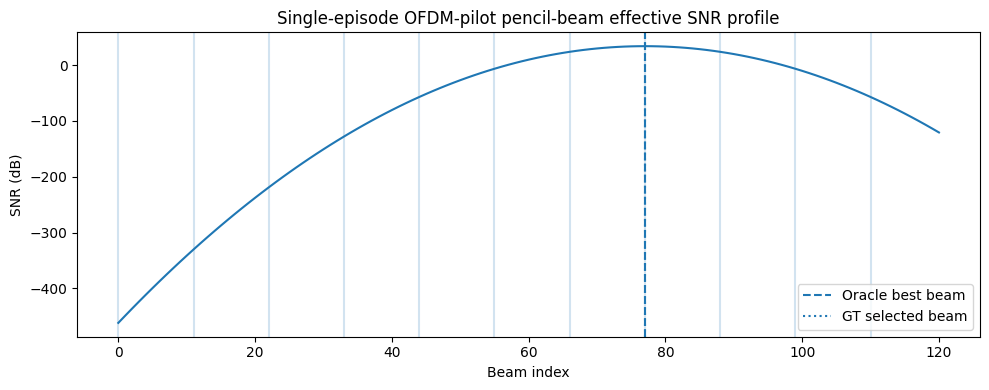

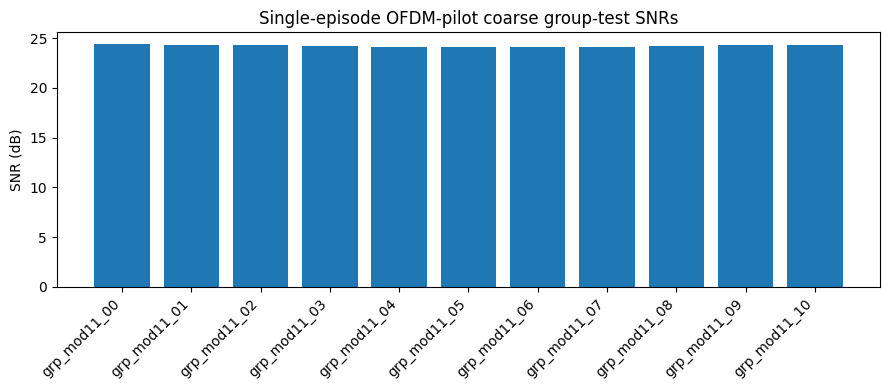

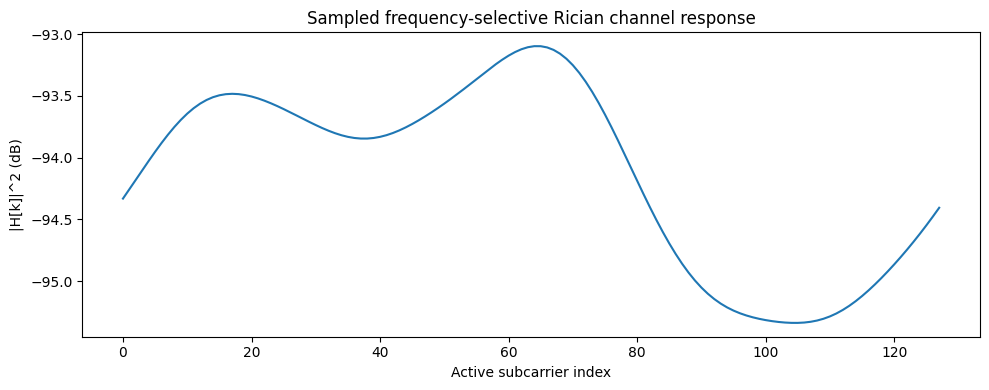

In [7]:
rng = np.random.default_rng(123)
fading = channel.sample_fading(rng=rng, range_m=range_m, blocked=blocked)

ue_fixed = geometry.sample_ue(
    force_theta_deg=theta_deg,
    force_range_m=range_m,
    blocked=blocked,
)

oracle_snr_db = channel.oracle_pencil_snr_vector_db(ue_fixed, fading=fading)
coarse_snr_db, group_names = channel.group_snr_vector_db(ue_fixed, fading=fading)
h_power_db = 10.0 * np.log10(np.maximum(np.abs(fading.frequency_response) ** 2, 1e-300))

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.arange(len(oracle_snr_db)), oracle_snr_db)
ax.axvline(ep_ex.oracle_best_beam_index, linestyle="--", label="Oracle best beam")
ax.axvline(ep_gt.selected_beam_index, linestyle=":", label="GT selected beam")
for idx in ep_gt.search_result.candidate_indices:
    ax.axvline(idx, alpha=0.2)
ax.set_xlabel("Beam index")
ax.set_ylabel("SNR (dB)")
ax.set_title("Single-episode OFDM-pilot pencil-beam effective SNR profile")
ax.legend()
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1)
ax.bar(np.arange(len(group_names)), coarse_snr_db)
ax.set_xticks(np.arange(len(group_names)))
ax.set_xticklabels(group_names, rotation=45, ha="right")
ax.set_ylabel("SNR (dB)")
ax.set_title("Single-episode OFDM-pilot coarse group-test SNRs")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.arange(len(h_power_db)), h_power_db)
ax.set_xlabel("Active subcarrier index")
ax.set_ylabel("|H[k]|^2 (dB)")
ax.set_title("Sampled frequency-selective Rician channel response")
plt.tight_layout()
plt.show()


## 5. Experiment 1: Baseline comparison

### Purpose

This is the main result of the paper.

We compare:
- exhaustive search
- group testing

over many random UE placements.

### Metrics

We report:
- average number of probes
- attach success probability
- exact oracle-beam match rate
- average beam-index error
- average final SNR

This experiment answers the central question:

> Does the proposed group-testing strategy reduce probing overhead while preserving useful attach performance?


,method,avg_probes,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,probe_reduction_vs_exhaustive
0,exhaustive,121.0,1.0,1.0000,0.0000,30.424389,0.000000
1,group_testing,22.0,1.0,0.8375,0.3375,30.363227,0.818182


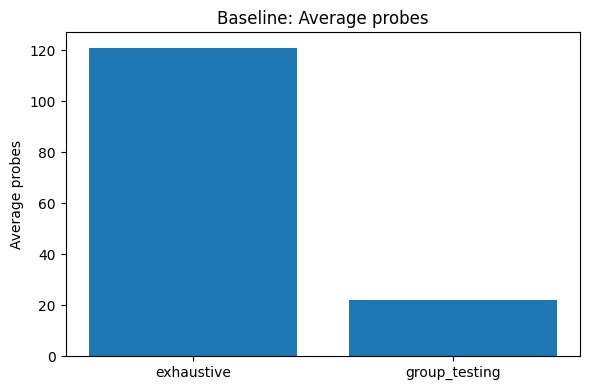

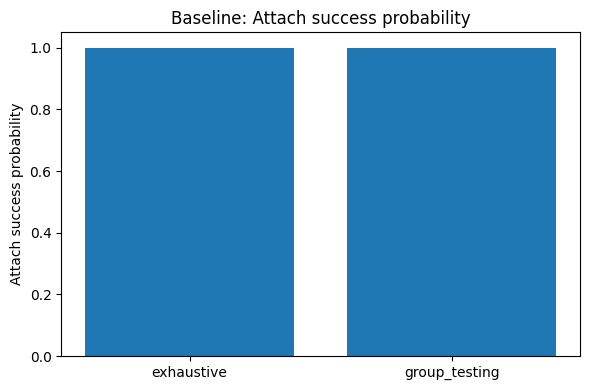

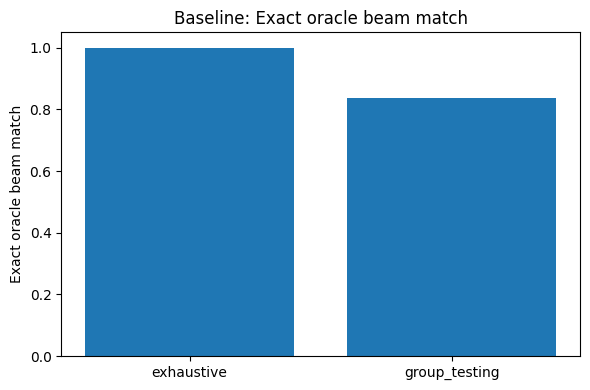

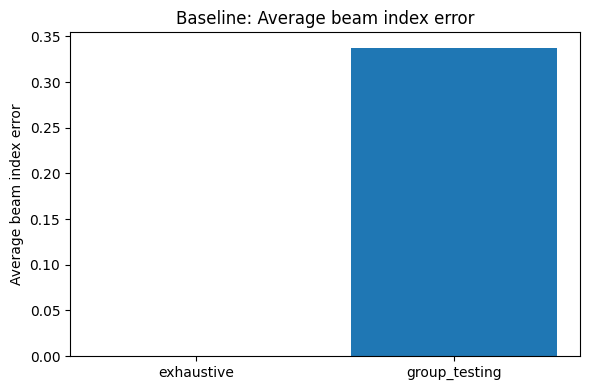

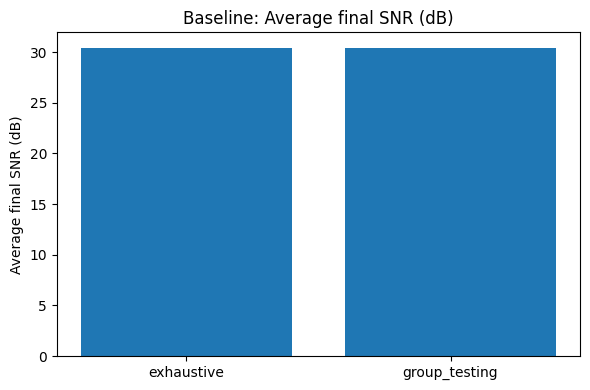

In [8]:
N_BASELINE = 400

_, sim_base = build_simulator(
    seed=7,
    num_episodes=N_BASELINE,
    detection_threshold_db=-5.0,
    blockage_probability=0.0,
)

df_ex_base = run_many(sim_base, "exhaustive", N_BASELINE, seed=100)
df_gt_base = run_many(sim_base, "group_testing", N_BASELINE, seed=100)

df_base = pd.concat([df_ex_base, df_gt_base], ignore_index=True)
summary_base = summarize_results(df_base)

display(summary_base)
plot_summary_bars(summary_base, title_prefix="Baseline: ")


## 6. Experiment 2: Range sensitivity

### Purpose

A method that looks good on average may still fail near the cell edge.  
This experiment checks how performance varies with UE distance.

### What is measured

We group the UEs by distance and compare:
- attach success
- beam error
- final SNR

This helps determine whether the proposed method degrades gracefully as the UE moves farther from the gNB.


In [9]:
df_range = df_base.copy()
df_range["range_bin_m"] = pd.cut(
    df_range["ue_range_m"],
    bins=[10, 25, 40, 55, 70, 85, 100],
    include_lowest=True,
)

range_summary = (
    df_range.groupby(["method", "range_bin_m"], as_index=False)
    .agg(
        attach_success=("attached", "mean"),
        exact_beam_match=("selected_equals_oracle", "mean"),
        avg_beam_error=("beam_index_error", "mean"),
        avg_final_snr_db=("final_snr_db", "mean"),
    )
)

display(range_summary.head(12))


,method,range_bin_m,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db
0,exhaustive,"(9.999, 25.0]",1.0,1.000000,0.000000,40.328374
1,exhaustive,"(25.0, 40.0]",1.0,1.000000,0.000000,35.910354
2,exhaustive,"(40.0, 55.0]",1.0,1.000000,0.000000,32.400072
3,exhaustive,"(55.0, 70.0]",1.0,1.000000,0.000000,30.478735
4,exhaustive,"(70.0, 85.0]",1.0,1.000000,0.000000,28.979928
5,exhaustive,"(85.0, 100.0]",1.0,1.000000,0.000000,26.943913
6,group_testing,"(9.999, 25.0]",1.0,1.000000,0.000000,40.328374
7,group_testing,"(25.0, 40.0]",1.0,0.729730,0.594595,35.803558
8,group_testing,"(40.0, 55.0]",1.0,0.887097,0.209677,32.362233
9,group_testing,"(55.0, 70.0]",1.0,0.840000,0.346667,30.413729


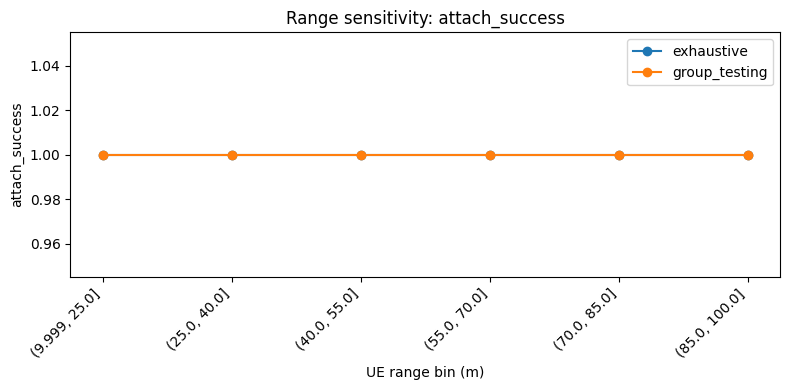

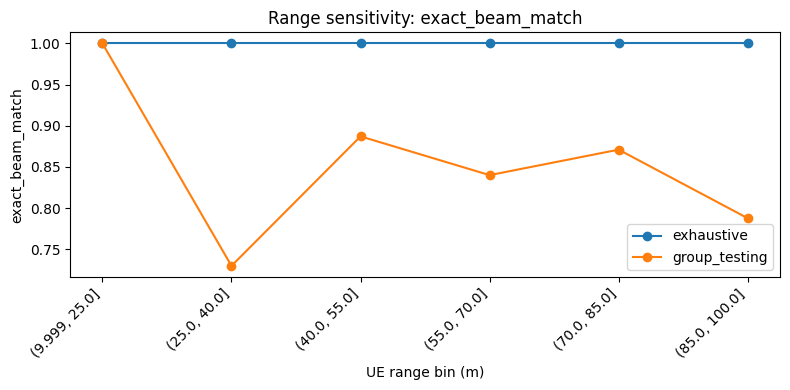

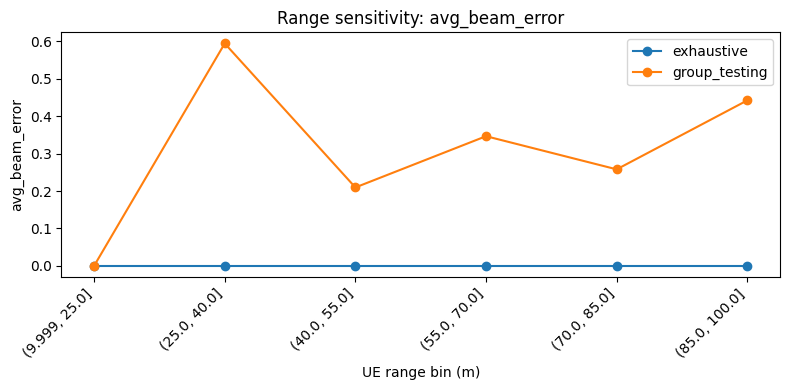

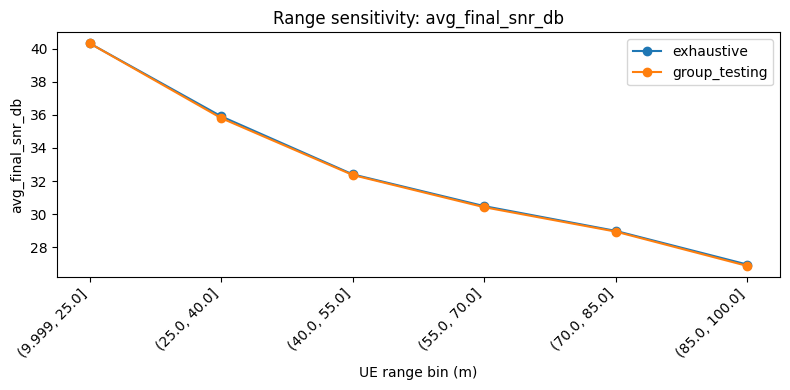

In [10]:
for metric in ["attach_success", "exact_beam_match", "avg_beam_error", "avg_final_snr_db"]:
    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(1, 1, 1)

    for method in range_summary["method"].unique():
        sub = range_summary[range_summary["method"] == method]
        ax.plot(sub["range_bin_m"].astype(str), sub[metric], marker="o", label=method)

    ax.set_title(f"Range sensitivity: {metric}")
    ax.set_xlabel("UE range bin (m)")
    ax.set_ylabel(metric)
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 7. Experiment 3: Detection-threshold sensitivity

### Purpose

The current simulator is driven by thresholded SNR feedback.  
This means the detection threshold is a fundamental parameter.

### What this experiment does

We rebuild the simulator for several thresholds and compare:
- attach success
- beam error
- final SNR

This tells us whether the beam-search method is robust when detection becomes stricter.


In [11]:
thresholds_db = [-10, -7, -5, -3, 0]
threshold_rows = []

for thr in thresholds_db:
    _, sim_thr = build_simulator(
        seed=7,
        num_episodes=250,
        detection_threshold_db=thr,
        blockage_probability=0.0,
    )

    df_ex_thr = run_many(sim_thr, "exhaustive", 250, seed=200)
    df_gt_thr = run_many(sim_thr, "group_testing", 250, seed=200)

    for method, df_thr in [("exhaustive", df_ex_thr), ("group_testing", df_gt_thr)]:
        threshold_rows.append(
            {
                "threshold_db": thr,
                "method": method,
                "attach_success": df_thr["attached"].mean(),
                "exact_beam_match": df_thr["selected_equals_oracle"].mean(),
                "avg_beam_error": df_thr["beam_index_error"].mean(),
                "avg_final_snr_db": df_thr["final_snr_db"].mean(),
                "avg_probes": df_thr["num_total_probes"].mean(),
            }
        )

df_threshold = pd.DataFrame(threshold_rows)
display(df_threshold)


,threshold_db,method,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,avg_probes
0,-10,exhaustive,1.0,1.000,0.000,29.712507,121.0
1,-10,group_testing,1.0,0.852,0.328,29.652923,22.0
2,-7,exhaustive,1.0,1.000,0.000,29.712507,121.0
3,-7,group_testing,1.0,0.852,0.328,29.652923,22.0
4,-5,exhaustive,1.0,1.000,0.000,29.712507,121.0
5,-5,group_testing,1.0,0.852,0.328,29.652923,22.0
6,-3,exhaustive,1.0,1.000,0.000,29.712507,121.0
7,-3,group_testing,1.0,0.852,0.328,29.652923,22.0
8,0,exhaustive,1.0,1.000,0.000,29.712507,121.0
9,0,group_testing,1.0,0.852,0.328,29.652923,22.0


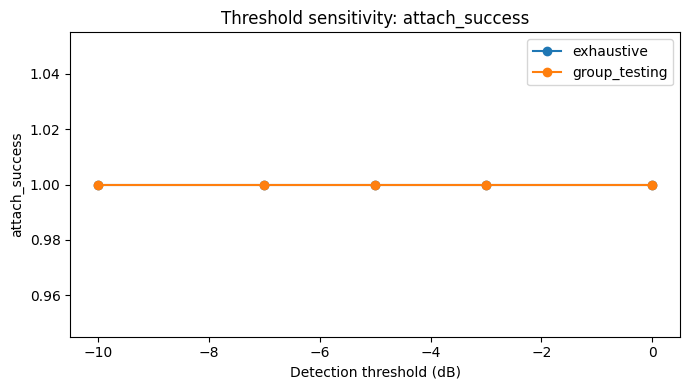

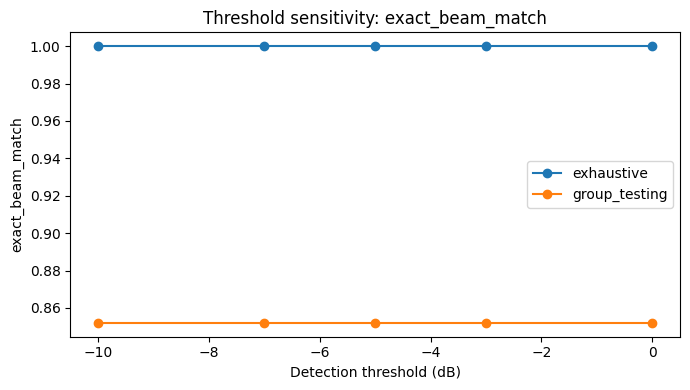

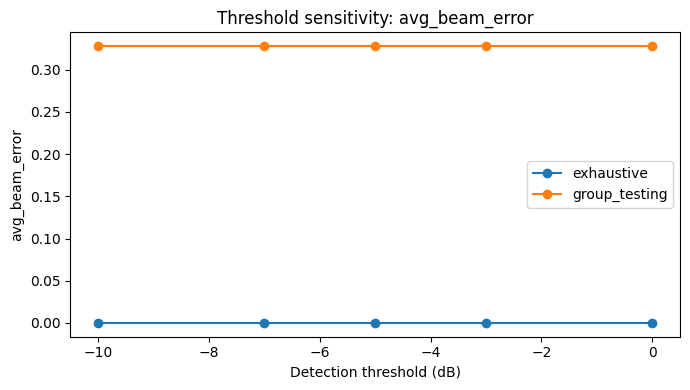

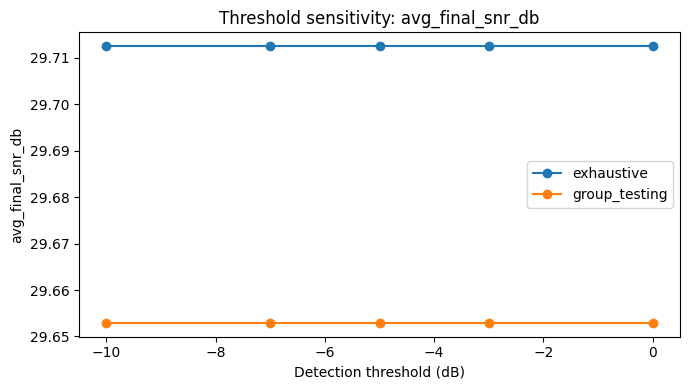

In [12]:
for metric in ["attach_success", "exact_beam_match", "avg_beam_error", "avg_final_snr_db"]:
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(1, 1, 1)

    for method in df_threshold["method"].unique():
        sub = df_threshold[df_threshold["method"] == method]
        ax.plot(sub["threshold_db"], sub[metric], marker="o", label=method)

    ax.set_title(f"Threshold sensitivity: {metric}")
    ax.set_xlabel("Detection threshold (dB)")
    ax.set_ylabel(metric)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Experiment 4: Blockage sensitivity

### Purpose

The minimal simulator includes an optional blockage model.  
This experiment checks how the methods behave when some UEs incur a blockage penalty.

### What this experiment does

We vary the blockage probability and compare:
- attach success
- beam error
- final SNR

This is useful because mmWave links can be fragile under blockage, even in a simplified simulator.


In [13]:
blockage_probs = [0.0, 0.1, 0.25, 0.4]
blockage_rows = []

for p_block in blockage_probs:
    _, sim_blk = build_simulator(
        seed=7,
        num_episodes=250,
        detection_threshold_db=-5.0,
        blockage_probability=p_block,
        blockage_loss_db=20.0,
    )

    df_ex_blk = run_many(sim_blk, "exhaustive", 250, seed=300)
    df_gt_blk = run_many(sim_blk, "group_testing", 250, seed=300)

    for method, df_blk in [("exhaustive", df_ex_blk), ("group_testing", df_gt_blk)]:
        blockage_rows.append(
            {
                "blockage_probability": p_block,
                "method": method,
                "attach_success": df_blk["attached"].mean(),
                "exact_beam_match": df_blk["selected_equals_oracle"].mean(),
                "avg_beam_error": df_blk["beam_index_error"].mean(),
                "avg_final_snr_db": df_blk["final_snr_db"].mean(),
                "avg_probes": df_blk["num_total_probes"].mean(),
            }
        )

df_blockage = pd.DataFrame(blockage_rows)
display(df_blockage)


,blockage_probability,method,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,avg_probes
0,0.00,exhaustive,1.000,1.000,0.000,30.355965,121.0
1,0.00,group_testing,1.000,0.844,0.320,30.294761,22.0
2,0.10,exhaustive,1.000,1.000,0.000,28.595965,121.0
3,0.10,group_testing,1.000,0.844,0.320,28.534761,22.0
4,0.25,exhaustive,1.000,1.000,0.000,25.555965,121.0
5,0.25,group_testing,0.996,0.840,0.332,25.490791,22.0
6,0.40,exhaustive,1.000,1.000,0.000,22.515965,121.0
7,0.40,group_testing,0.988,0.832,0.360,22.441631,22.0


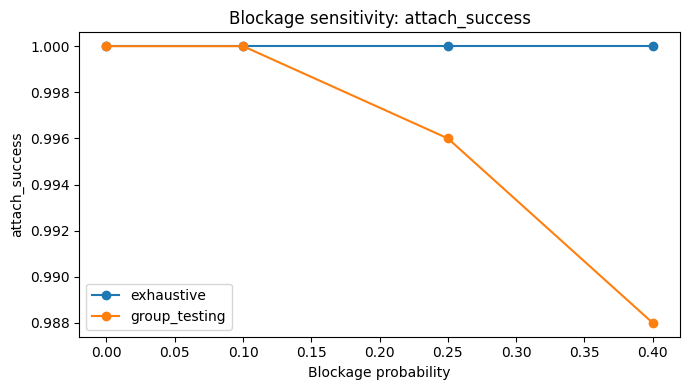

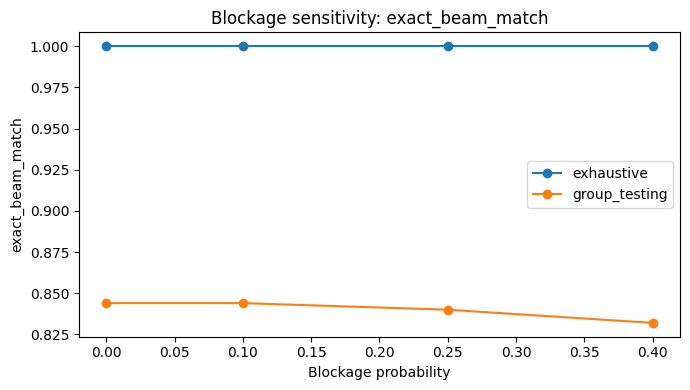

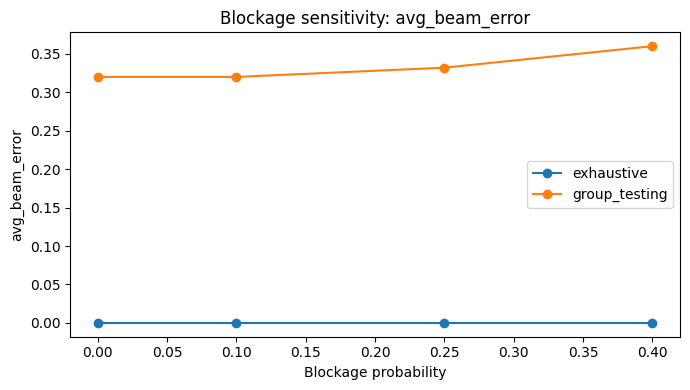

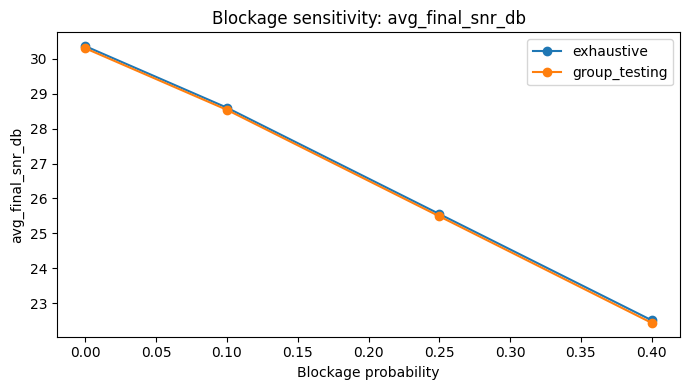

In [14]:
for metric in ["attach_success", "exact_beam_match", "avg_beam_error", "avg_final_snr_db"]:
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(1, 1, 1)

    for method in df_blockage["method"].unique():
        sub = df_blockage[df_blockage["method"] == method]
        ax.plot(sub["blockage_probability"], sub[metric], marker="o", label=method)

    ax.set_title(f"Blockage sensitivity: {metric}")
    ax.set_xlabel("Blockage probability")
    ax.set_ylabel(metric)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [15]:
print("Baseline summary")
display(summary_base)

print("Range summary")
display(range_summary)

print("Threshold sweep summary")
display(df_threshold)

print("Blockage sweep summary")
display(df_blockage)


Baseline summary


,method,avg_probes,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,probe_reduction_vs_exhaustive
0,exhaustive,121.0,1.0,1.0000,0.0000,30.424389,0.000000
1,group_testing,22.0,1.0,0.8375,0.3375,30.363227,0.818182


Range summary


,method,range_bin_m,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db
0,exhaustive,"(9.999, 25.0]",1.0,1.000000,0.000000,40.328374
1,exhaustive,"(25.0, 40.0]",1.0,1.000000,0.000000,35.910354
2,exhaustive,"(40.0, 55.0]",1.0,1.000000,0.000000,32.400072
3,exhaustive,"(55.0, 70.0]",1.0,1.000000,0.000000,30.478735
4,exhaustive,"(70.0, 85.0]",1.0,1.000000,0.000000,28.979928
5,exhaustive,"(85.0, 100.0]",1.0,1.000000,0.000000,26.943913
6,group_testing,"(9.999, 25.0]",1.0,1.000000,0.000000,40.328374
7,group_testing,"(25.0, 40.0]",1.0,0.729730,0.594595,35.803558
8,group_testing,"(40.0, 55.0]",1.0,0.887097,0.209677,32.362233
9,group_testing,"(55.0, 70.0]",1.0,0.840000,0.346667,30.413729


Threshold sweep summary


,threshold_db,method,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,avg_probes
0,-10,exhaustive,1.0,1.000,0.000,29.712507,121.0
1,-10,group_testing,1.0,0.852,0.328,29.652923,22.0
2,-7,exhaustive,1.0,1.000,0.000,29.712507,121.0
3,-7,group_testing,1.0,0.852,0.328,29.652923,22.0
4,-5,exhaustive,1.0,1.000,0.000,29.712507,121.0
5,-5,group_testing,1.0,0.852,0.328,29.652923,22.0
6,-3,exhaustive,1.0,1.000,0.000,29.712507,121.0
7,-3,group_testing,1.0,0.852,0.328,29.652923,22.0
8,0,exhaustive,1.0,1.000,0.000,29.712507,121.0
9,0,group_testing,1.0,0.852,0.328,29.652923,22.0


Blockage sweep summary


,blockage_probability,method,attach_success,exact_beam_match,avg_beam_error,avg_final_snr_db,avg_probes
0,0.00,exhaustive,1.000,1.000,0.000,30.355965,121.0
1,0.00,group_testing,1.000,0.844,0.320,30.294761,22.0
2,0.10,exhaustive,1.000,1.000,0.000,28.595965,121.0
3,0.10,group_testing,1.000,0.844,0.320,28.534761,22.0
4,0.25,exhaustive,1.000,1.000,0.000,25.555965,121.0
5,0.25,group_testing,0.996,0.840,0.332,25.490791,22.0
6,0.40,exhaustive,1.000,1.000,0.000,22.515965,121.0
7,0.40,group_testing,0.988,0.832,0.360,22.441631,22.0
